170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2268s 13us/step
Dataset dimensions:
X_train: (50000, 32, 32, 3), y_train: (50000,)
X_test: (10000, 32, 32, 3), y_test: (10000,)
Classes: 10
Image size: 32x32x3


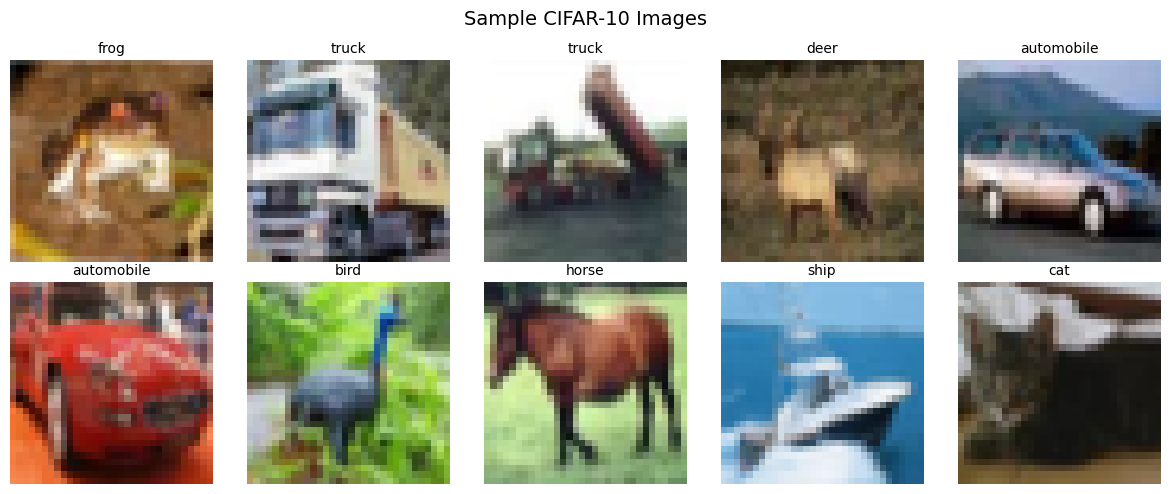

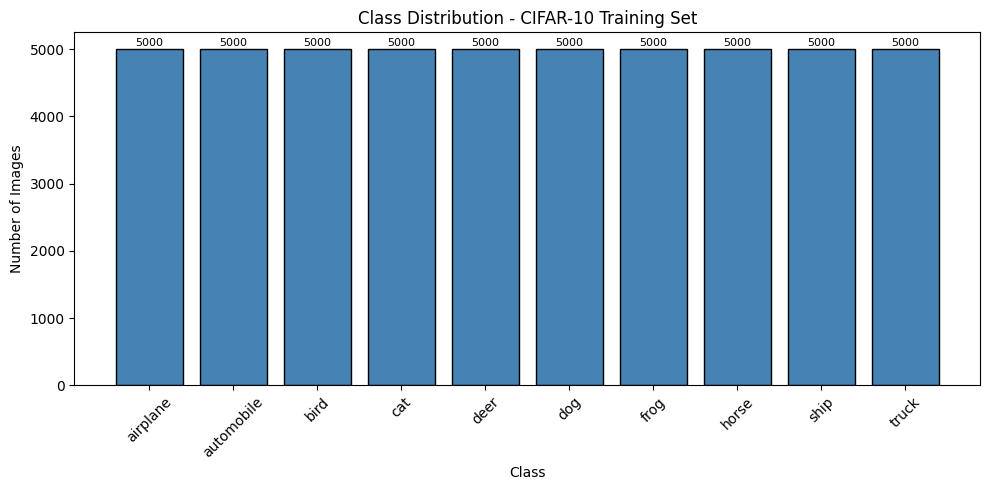

In [2]:
# Cell 1: Setup + Task 1 - Load CIFAR-10
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
import os

# Folder to collect all plots for final zip
os.makedirs('/content/plots', exist_ok=True)

# Load CIFAR-10
(X_train, y_train), (X_test, y_test) = keras.datasets.cifar10.load_data()
y_train = y_train.flatten()
y_test = y_test.flatten()

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

print("Dataset dimensions:")
print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_test: {X_test.shape}, y_test: {y_test.shape}")
print(f"Classes: {len(class_names)}")
print(f"Image size: {X_train.shape[1]}x{X_train.shape[2]}x{X_train.shape[3]}")

# Plot 1: Sample images
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i])
    ax.set_title(class_names[y_train[i]], fontsize=10)
    ax.axis('off')
plt.suptitle('Sample CIFAR-10 Images', fontsize=14)
plt.tight_layout()
plt.savefig('/content/plots/01_sample_images.png', dpi=300, bbox_inches='tight')
plt.show()

# Plot 2: Class distribution
unique, counts = np.unique(y_train, return_counts=True)
plt.figure(figsize=(10, 5))
bars = plt.bar([class_names[i] for i in unique], counts, color='steelblue', edgecolor='black')
plt.xlabel('Class')
plt.ylabel('Number of Images')
plt.title('Class Distribution - CIFAR-10 Training Set')
plt.xticks(rotation=45)
for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50, str(count),
             ha='center', fontsize=8)
plt.tight_layout()
plt.savefig('/content/plots/02_class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

Kernel 3x3 -> Output feature map shape: (30, 30, 8)
Kernel 5x5 -> Output feature map shape: (28, 28, 8)
Kernel 7x7 -> Output feature map shape: (26, 26, 8)

Formula verification (N=32, P=0, S=1):
Kernel 3x3: calculated=30, actual=30
Kernel 5x5: calculated=28, actual=28
Kernel 7x7: calculated=26, actual=26


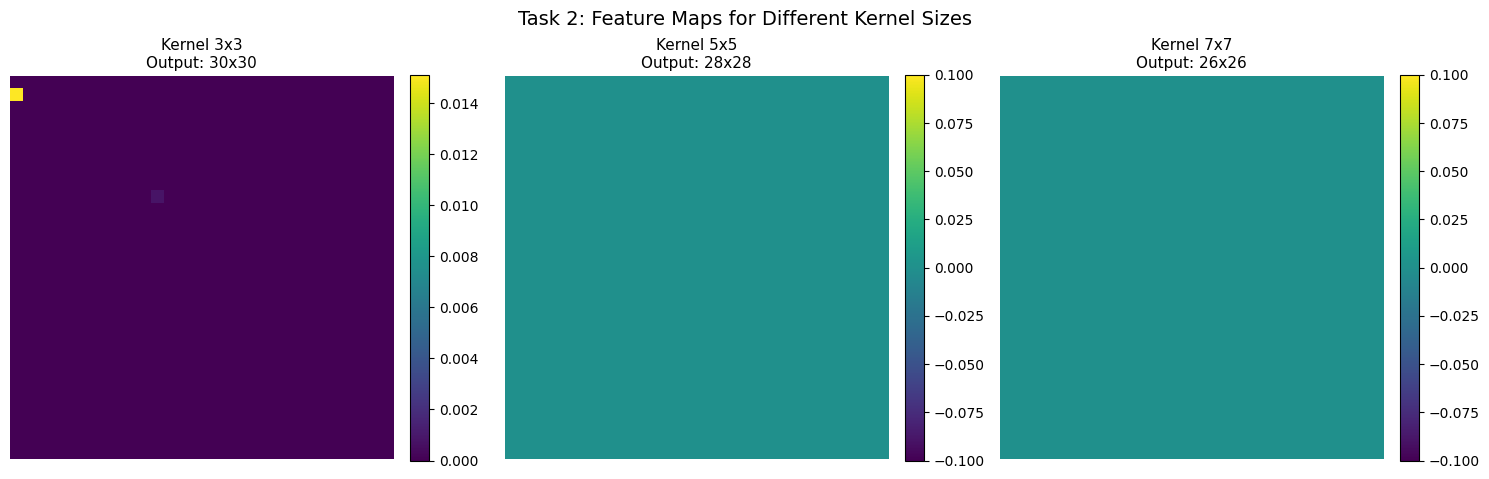


Kernel Size  Output Shape         Feature Map Dim
3x3          (30, 30)             30x30          
5x5          (28, 28)             28x28          
7x7          (26, 26)             26x26          


In [3]:
# Cell 2: Task 2 - Kernel Size Comparison
sample_img = X_train[0:1].astype('float32') / 255.0  # shape (1, 32, 32, 3)

kernel_sizes = [3, 5, 7]
feature_maps = {}
output_shapes = {}

for k in kernel_sizes:
    conv_layer = keras.layers.Conv2D(filters=8, kernel_size=k, strides=1,
                                      padding='valid', activation='relu')
    fmap = conv_layer(sample_img)
    feature_maps[k] = fmap
    output_shapes[k] = fmap.shape
    print(f"Kernel {k}x{k} -> Output feature map shape: {fmap.shape[1:]}")

# Formula check: N - F + 2P/S + 1 (P=0, S=1, valid padding)
print("\nFormula verification (N=32, P=0, S=1):")
for k in kernel_sizes:
    calc_size = (32 - k + 2*0)//1 + 1
    print(f"Kernel {k}x{k}: calculated={calc_size}, actual={output_shapes[k][1]}")

# Plot: visualize one feature map channel per kernel size, side by side
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for idx, k in enumerate(kernel_sizes):
    fmap = feature_maps[k][0, :, :, 0].numpy()
    im = axes[idx].imshow(fmap, cmap='viridis')
    axes[idx].set_title(f'Kernel {k}x{k}\nOutput: {output_shapes[k][1]}x{output_shapes[k][2]}',
                         fontsize=11)
    axes[idx].axis('off')
    plt.colorbar(im, ax=axes[idx], fraction=0.046, pad=0.04)
plt.suptitle('Task 2: Feature Maps for Different Kernel Sizes', fontsize=14)
plt.tight_layout()
plt.savefig('/content/plots/03_kernel_size_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# Table summary
print("\n{:<12} {:<20} {:<15}".format("Kernel Size", "Output Shape", "Feature Map Dim"))
for k in kernel_sizes:
    print("{:<12} {:<20} {:<15}".format(f"{k}x{k}", str(output_shapes[k][1:3]), f"{output_shapes[k][1]}x{output_shapes[k][2]}"))

Stride=1, Padding=Valid -> Output shape: (30, 30)
Stride=2, Padding=Valid -> Output shape: (15, 15)
Stride=1, Padding=Same -> Output shape: (32, 32)
Stride=2, Padding=Same -> Output shape: (16, 16)

Formula verification (N=32, F=3):
Stride=1, Padding=Valid: calculated=30
Stride=2, Padding=Valid: calculated=15
Stride=1, Padding=Same: calculated=32
Stride=2, Padding=Same: calculated=16


/tmp/ipykernel_791/2304873952.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=20, ha='right')


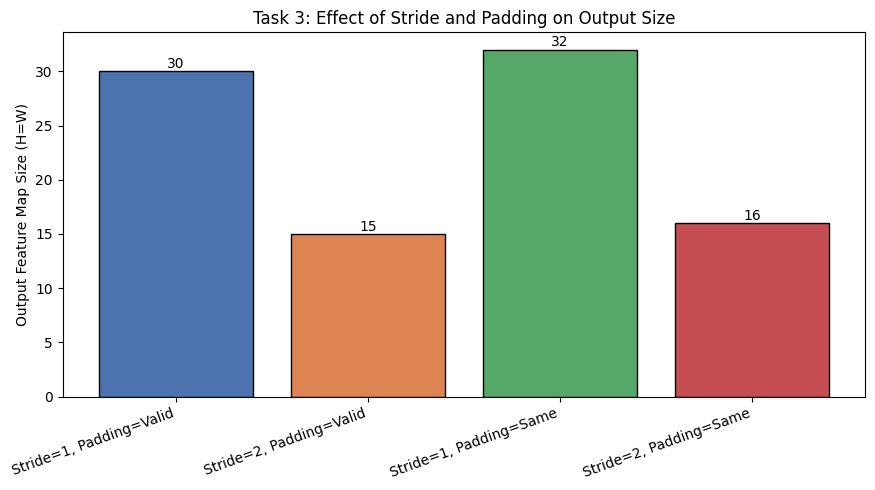


Configuration                Output Size
Stride=1, Padding=Valid      (30, 30)  
Stride=2, Padding=Valid      (15, 15)  
Stride=1, Padding=Same       (32, 32)  
Stride=2, Padding=Same       (16, 16)  


In [4]:
# Cell 3: Task 3 - Stride & Padding Comparison
configs = [
    {'stride': 1, 'padding': 'valid', 'label': 'Stride=1, Padding=Valid'},
    {'stride': 2, 'padding': 'valid', 'label': 'Stride=2, Padding=Valid'},
    {'stride': 1, 'padding': 'same',  'label': 'Stride=1, Padding=Same'},
    {'stride': 2, 'padding': 'same',  'label': 'Stride=2, Padding=Same'},
]

results = []
fmap_results = []

for cfg in configs:
    conv_layer = keras.layers.Conv2D(filters=8, kernel_size=3,
                                      strides=cfg['stride'], padding=cfg['padding'],
                                      activation='relu')
    fmap = conv_layer(sample_img)
    results.append({
        'label': cfg['label'],
        'stride': cfg['stride'],
        'padding': cfg['padding'],
        'output_shape': fmap.shape[1:3]
    })
    fmap_results.append(fmap)
    print(f"{cfg['label']} -> Output shape: {fmap.shape[1:3]}")

# Manual formula check for 'valid' cases: N - F + 2P/S + 1  (P=0 for valid)
# For 'same' padding, Keras auto-pads so output = ceil(N/S)
print("\nFormula verification (N=32, F=3):")
for cfg in configs:
    N, F, S = 32, 3, cfg['stride']
    if cfg['padding'] == 'valid':
        calc = (N - F) // S + 1
    else:  # same
        calc = -(-N // S)  # ceil division
    print(f"{cfg['label']}: calculated={calc}")

# Plot: comparison bar chart of output dims
fig, ax = plt.subplots(figsize=(9, 5))
labels = [r['label'] for r in results]
sizes = [r['output_shape'][0] for r in results]
bars = ax.bar(labels, sizes, color=['#4C72B0', '#DD8452', '#55A868', '#C44E52'], edgecolor='black')
ax.set_ylabel('Output Feature Map Size (H=W)')
ax.set_title('Task 3: Effect of Stride and Padding on Output Size')
ax.set_xticklabels(labels, rotation=20, ha='right')
for bar, s in zip(bars, sizes):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, str(s), ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('/content/plots/04_stride_padding_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# Table
print("\n{:<28} {:<10}".format("Configuration", "Output Size"))
for r in results:
    print("{:<28} {:<10}".format(r['label'], str(r['output_shape'])))

Feature maps shape: (1, 32, 32, 16)
Number of channels (filters): 16


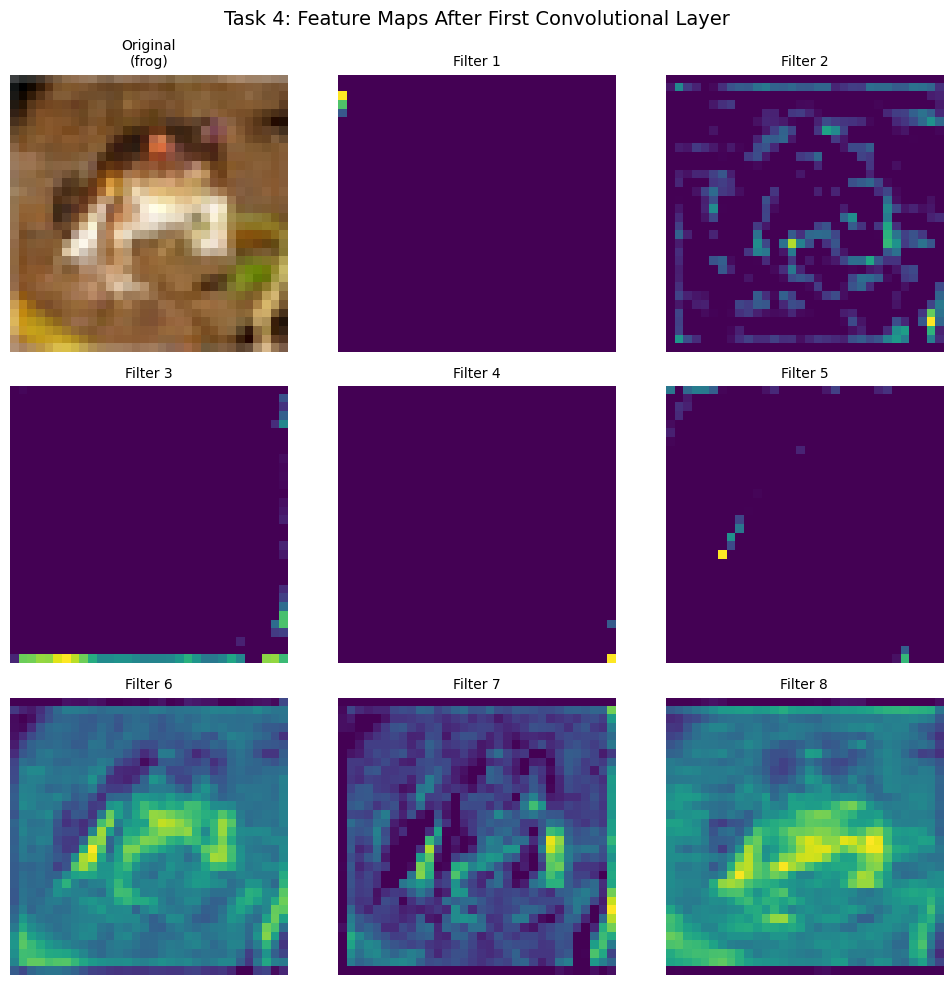

In [5]:
# Cell 4: Task 4 - Visualize Feature Maps (First Conv Layer)
first_conv = keras.layers.Conv2D(filters=16, kernel_size=3, strides=1,
                                  padding='same', activation='relu')
feature_maps_task4 = first_conv(sample_img)  # shape (1, 32, 32, 16)

print(f"Feature maps shape: {feature_maps_task4.shape}")
print(f"Number of channels (filters): {feature_maps_task4.shape[-1]}")

# Plot original image + 8 feature maps
n_maps = 8
fig, axes = plt.subplots(3, 3, figsize=(10, 10))
axes = axes.flat

axes[0].imshow(sample_img[0])
axes[0].set_title(f'Original\n({class_names[y_train[0]]})', fontsize=10)
axes[0].axis('off')

for i in range(n_maps):
    fmap = feature_maps_task4[0, :, :, i].numpy()
    axes[i+1].imshow(fmap, cmap='viridis')
    axes[i+1].set_title(f'Filter {i+1}', fontsize=10)
    axes[i+1].axis('off')

plt.suptitle('Task 4: Feature Maps After First Convolutional Layer', fontsize=14)
plt.tight_layout()
plt.savefig('/content/plots/05_feature_maps_first_conv.png', dpi=300, bbox_inches='tight')
plt.show()

Input feature map shape: (32, 32)
MaxPool output shape: (16, 16)
AvgPool output shape: (16, 16)


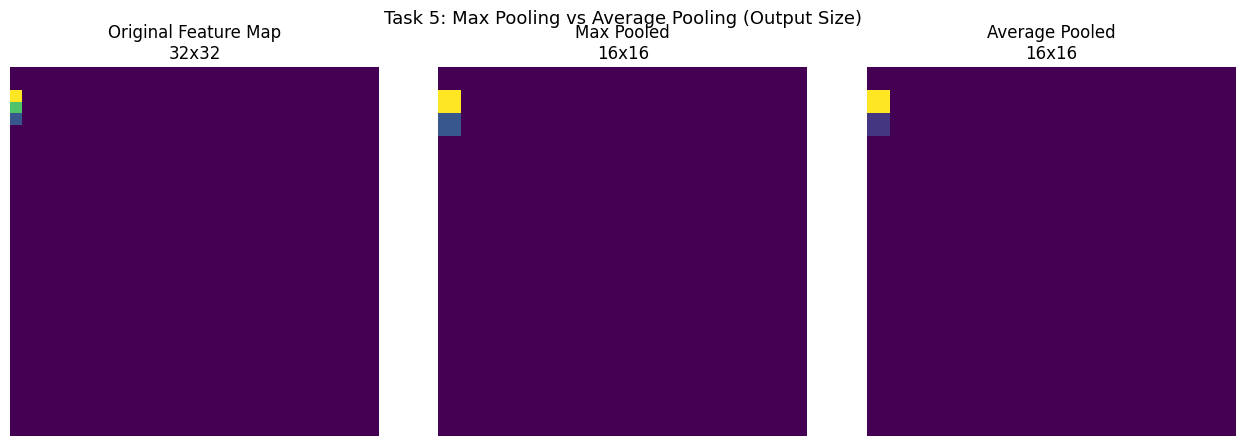


Training quick CNN with MaxPooling...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.4324 - loss: 1.5828 - val_accuracy: 0.5480 - val_loss: 1.2955
Epoch 2/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5633 - loss: 1.2468 - val_accuracy: 0.5914 - val_loss: 1.1659
Epoch 3/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6115 - loss: 1.1128 - val_accuracy: 0.6198 - val_loss: 1.1063
Epoch 4/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6397 - loss: 1.0316 - val_accuracy: 0.6272 - val_loss: 1.0598
Epoch 5/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6600 - loss: 0.9760 - val_accuracy: 0.6418 - val_loss: 1.0297

Training quick CNN with AveragePooling...
Epoch 1/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.4094 - loss: 1.6515 - val_accuracy: 0.4802 - val_loss: 1.4445
Epoch 2/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5163 - loss: 1.3528 - val_accuracy: 0.5434 - val_loss: 1.2858
Epoch 3/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.566

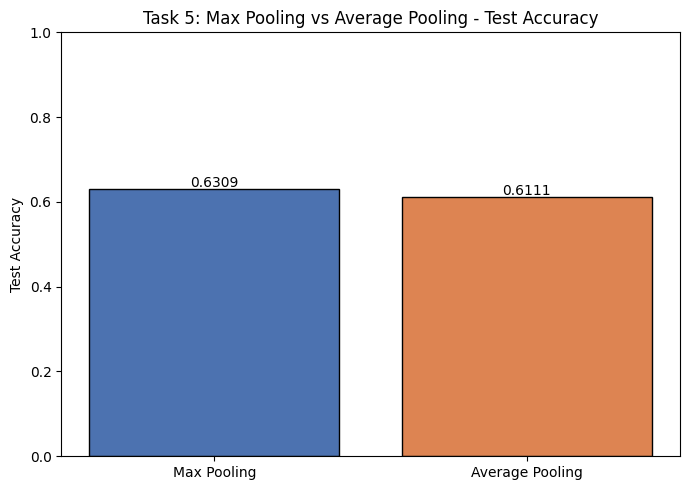

In [6]:
# Cell 5: Task 5 - Max Pooling vs Average Pooling
# Part A: Output size comparison on sample feature map
pool_size = 2
maxpool_layer = keras.layers.MaxPooling2D(pool_size=pool_size)
avgpool_layer = keras.layers.AveragePooling2D(pool_size=pool_size)

max_out = maxpool_layer(feature_maps_task4)
avg_out = avgpool_layer(feature_maps_task4)

print(f"Input feature map shape: {feature_maps_task4.shape[1:3]}")
print(f"MaxPool output shape: {max_out.shape[1:3]}")
print(f"AvgPool output shape: {avg_out.shape[1:3]}")

# Visual comparison of pooling effect on one channel
fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
axes[0].imshow(feature_maps_task4[0, :, :, 0].numpy(), cmap='viridis')
axes[0].set_title(f'Original Feature Map\n{feature_maps_task4.shape[1]}x{feature_maps_task4.shape[2]}')
axes[0].axis('off')
axes[1].imshow(max_out[0, :, :, 0].numpy(), cmap='viridis')
axes[1].set_title(f'Max Pooled\n{max_out.shape[1]}x{max_out.shape[2]}')
axes[1].axis('off')
axes[2].imshow(avg_out[0, :, :, 0].numpy(), cmap='viridis')
axes[2].set_title(f'Average Pooled\n{avg_out.shape[1]}x{avg_out.shape[2]}')
axes[2].axis('off')
plt.suptitle('Task 5: Max Pooling vs Average Pooling (Output Size)', fontsize=13)
plt.tight_layout()
plt.savefig('/content/plots/06_pooling_output_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# Part B: Accuracy comparison - quick small CNNs (5 epochs each) on normalized data
X_train_norm = X_train.astype('float32') / 255.0
X_test_norm = X_test.astype('float32') / 255.0

def build_small_cnn(pooling='max'):
    PoolLayer = keras.layers.MaxPooling2D if pooling == 'max' else keras.layers.AveragePooling2D
    model = keras.Sequential([
        keras.layers.Conv2D(16, 3, activation='relu', padding='same', input_shape=(32,32,3)),
        PoolLayer(2),
        keras.layers.Conv2D(32, 3, activation='relu', padding='same'),
        PoolLayer(2),
        keras.layers.Flatten(),
        keras.layers.Dense(64, activation='relu'),
        keras.layers.Dense(10, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

print("\nTraining quick CNN with MaxPooling...")
model_max = build_small_cnn('max')
hist_max = model_max.fit(X_train_norm, y_train, epochs=5, batch_size=64,
                          validation_split=0.1, verbose=1)
test_loss_max, test_acc_max = model_max.evaluate(X_test_norm, y_test, verbose=0)

print("\nTraining quick CNN with AveragePooling...")
model_avg = build_small_cnn('avg')
hist_avg = model_avg.fit(X_train_norm, y_train, epochs=5, batch_size=64,
                          validation_split=0.1, verbose=1)
test_loss_avg, test_acc_avg = model_avg.evaluate(X_test_norm, y_test, verbose=0)

print(f"\nMaxPooling  -> Test Accuracy: {test_acc_max:.4f}")
print(f"AveragePooling -> Test Accuracy: {test_acc_avg:.4f}")

# Plot accuracy comparison
plt.figure(figsize=(7,5))
bars = plt.bar(['Max Pooling', 'Average Pooling'], [test_acc_max, test_acc_avg],
                color=['#4C72B0', '#DD8452'], edgecolor='black')
plt.ylabel('Test Accuracy')
plt.title('Task 5: Max Pooling vs Average Pooling - Test Accuracy')
for bar, acc in zip(bars, [test_acc_max, test_acc_avg]):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005, f'{acc:.4f}', ha='center')
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig('/content/plots/07_pooling_accuracy_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

In [7]:
# Cell 6: Task 6 - Main CNN Architecture + Training
model = keras.Sequential([
    keras.layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
    keras.layers.MaxPooling2D((2,2)),
    keras.layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    keras.layers.MaxPooling2D((2,2)),
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
], name='CIFAR10_CNN')

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

# Save model summary as text for report
with open('/content/plots/model_summary.txt', 'w') as f:
    model.summary(print_fn=lambda x: f.write(x + '\n'))

total_params = model.count_params()
print(f"\nTotal trainable parameters: {total_params:,}")

# Train
history = model.fit(X_train_norm, y_train,
                     epochs=20, batch_size=32,
                     validation_split=0.1,
                     verbose=1)

# Evaluate on test set (save for Task 7)
test_loss, test_acc = model.evaluate(X_test_norm, y_test, verbose=0)
print(f"\nFinal Test Accuracy: {test_acc:.4f}")
print(f"Final Test Loss: {test_loss:.4f}")

Model: "CIFAR10_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545,098 (2.08 MB)

 Trainable params: 545,098 (2.08 MB)

 Non-trainable params: 0 (0.00 B)


Total trainable parameters: 545,098
Epoch 1/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.5036 - loss: 1.3873 - val_accuracy: 0.5746 - val_loss: 1.2078
Epoch 2/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6452 - loss: 1.0162 - val_accuracy: 0.6572 - val_loss: 0.9764
Epoch 3/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6956 - loss: 0.8734 - val_accuracy: 0.6906 - val_loss: 0.8996
Epoch 4/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7344 - loss: 0.7604 - val_accuracy: 0.7010 - val_loss: 0.8616
Epoch 5/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7684 - loss: 0.6636 - val_accuracy: 0.7108 - val_loss: 0.8625
Epoch 6/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7983 - loss: 0.5749 - val_accuracy: 0.7088 - val_loss: 0.8772
Epoch 7/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8274 - loss: 0.4919 - val_accuracy: 0.7208 - val_loss: 0.8631
Epoch 8/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/ste

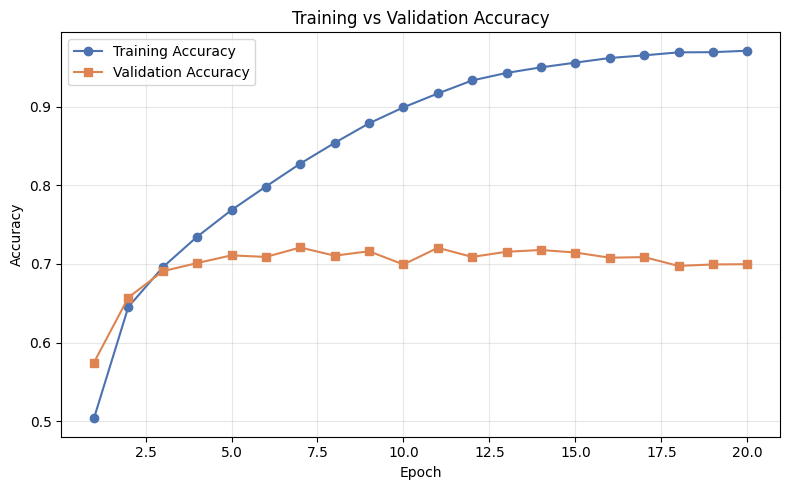

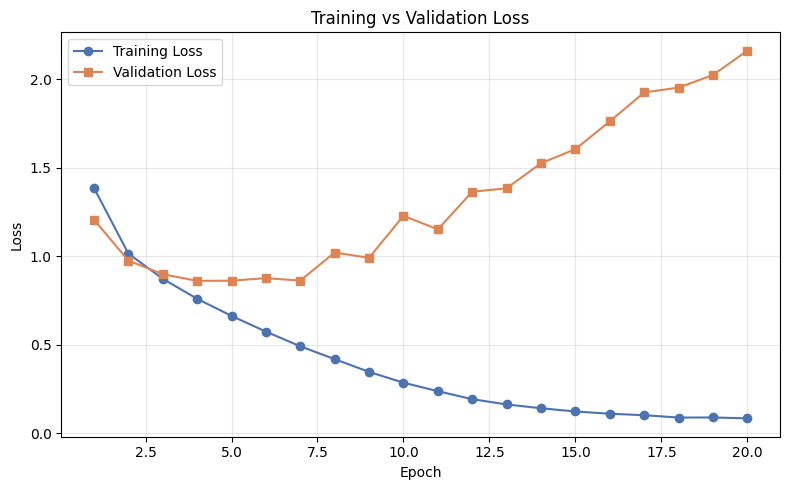

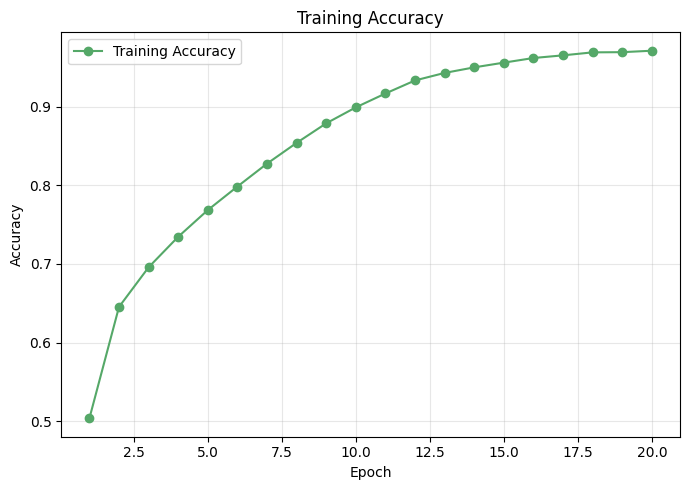

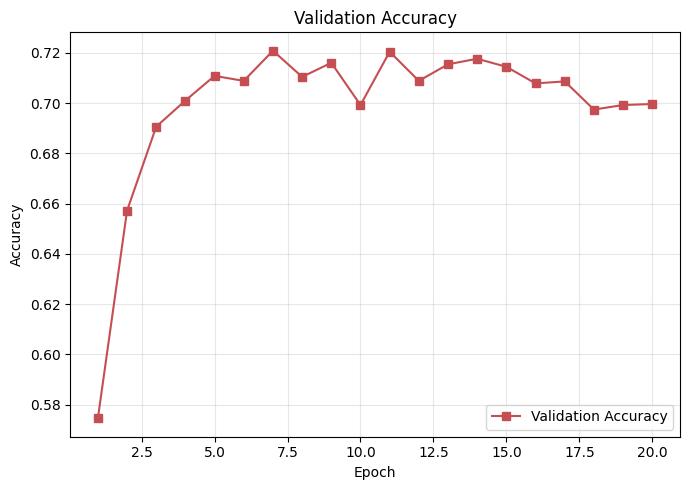

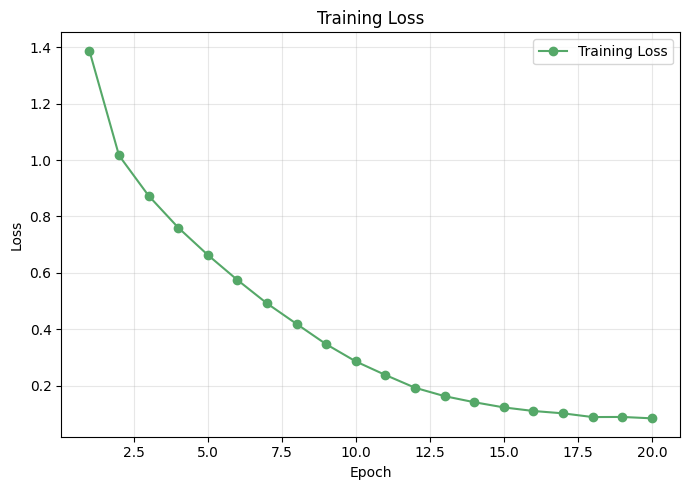

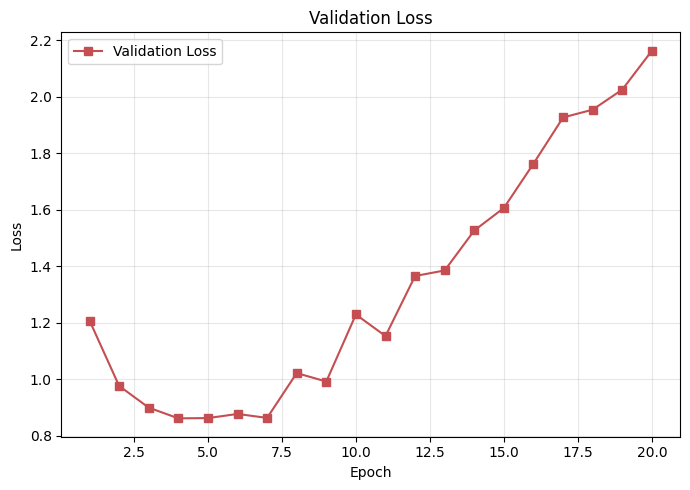

Validation loss was lowest at epoch 4 (0.8616)
Final validation loss: 2.1625
Validation loss increased after this point → sign of overfitting.


In [8]:
# Cell 7: Training Curves (Accuracy & Loss)
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(1, len(acc) + 1)

# Plot: Training vs Validation Accuracy
plt.figure(figsize=(8, 5))
plt.plot(epochs_range, acc, 'o-', color='#4C72B0', label='Training Accuracy')
plt.plot(epochs_range, val_acc, 's-', color='#DD8452', label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('/content/plots/08_training_accuracy.png', dpi=300, bbox_inches='tight')
plt.show()

# Plot: Training vs Validation Loss
plt.figure(figsize=(8, 5))
plt.plot(epochs_range, loss, 'o-', color='#4C72B0', label='Training Loss')
plt.plot(epochs_range, val_loss, 's-', color='#DD8452', label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('/content/plots/09_training_loss.png', dpi=300, bbox_inches='tight')
plt.show()

# Separate individual plots (mandatory list treats these as distinct items)
plt.figure(figsize=(7,5))
plt.plot(epochs_range, acc, 'o-', color='#55A868', label='Training Accuracy')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.title('Training Accuracy')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig('/content/plots/08a_training_accuracy_only.png', dpi=300, bbox_inches='tight')
plt.show()

plt.figure(figsize=(7,5))
plt.plot(epochs_range, val_acc, 's-', color='#C44E52', label='Validation Accuracy')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.title('Validation Accuracy')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig('/content/plots/08b_validation_accuracy_only.png', dpi=300, bbox_inches='tight')
plt.show()

plt.figure(figsize=(7,5))
plt.plot(epochs_range, loss, 'o-', color='#55A868', label='Training Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.title('Training Loss')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig('/content/plots/09a_training_loss_only.png', dpi=300, bbox_inches='tight')
plt.show()

plt.figure(figsize=(7,5))
plt.plot(epochs_range, val_loss, 's-', color='#C44E52', label='Validation Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.title('Validation Loss')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig('/content/plots/09b_validation_loss_only.png', dpi=300, bbox_inches='tight')
plt.show()

# Print epoch where val_loss starts increasing (overfitting point)
min_val_loss_epoch = np.argmin(val_loss) + 1
print(f"Validation loss was lowest at epoch {min_val_loss_epoch} ({val_loss[min_val_loss_epoch-1]:.4f})")
print(f"Final validation loss: {val_loss[-1]:.4f}")
if val_loss[-1] > val_loss[min_val_loss_epoch-1]:
    print("Validation loss increased after this point → sign of overfitting.")

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step
Test Accuracy:  0.6940
Precision (macro): 0.6997
Recall (macro):    0.6940
F1-score (macro):  0.6923

Classification Report:

              precision    recall  f1-score   support

    airplane       0.70      0.77      0.73      1000
  automobile       0.84      0.78      0.81      1000
        bird       0.66      0.53      0.59      1000
         cat       0.53      0.41      0.46      1000
        deer       0.69      0.59      0.64      1000
         dog       0.50      0.71      0.59      1000
        frog       0.72      0.80      0.76      1000
       horse       0.72      0.78      0.75      1000
        ship       0.86      0.77      0.81      1000
       truck       0.77      0.79      0.78      1000

    accuracy                           0.69     10000
   macro avg       0.70      0.69      0.69     10000
weighted avg       0.70      0.69      0.69     10000



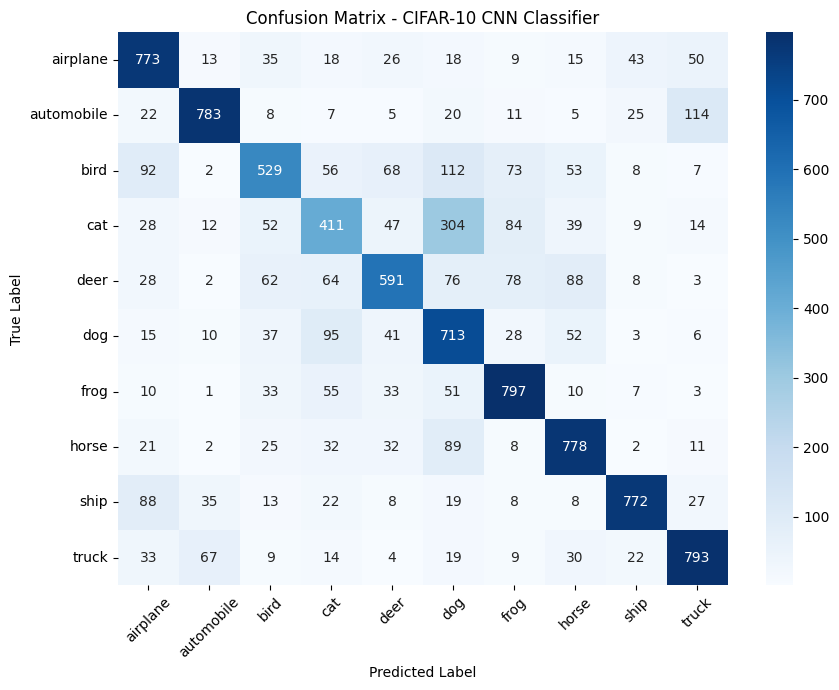

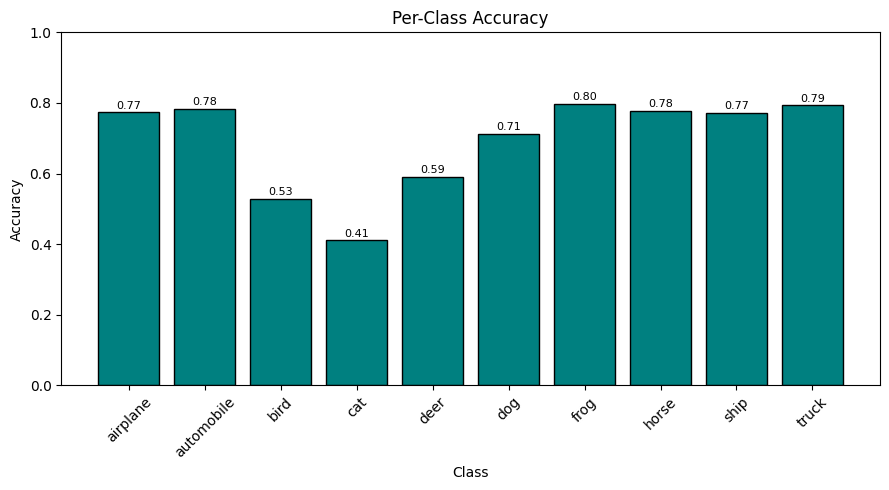


Best performing class: frog (0.7970)
Worst performing class: cat (0.4110)


In [9]:
# Cell 8: Task 7 - Evaluation Metrics
from sklearn.metrics import (precision_score, recall_score, f1_score,
                              confusion_matrix, classification_report, accuracy_score)
import seaborn as sns

# Predictions
y_pred_probs = model.predict(X_test_norm)
y_pred = np.argmax(y_pred_probs, axis=1)

# Metrics
test_accuracy = accuracy_score(y_test, y_pred)
precision_macro = precision_score(y_test, y_pred, average='macro')
recall_macro = recall_score(y_test, y_pred, average='macro')
f1_macro = f1_score(y_test, y_pred, average='macro')

print(f"Test Accuracy:  {test_accuracy:.4f}")
print(f"Precision (macro): {precision_macro:.4f}")
print(f"Recall (macro):    {recall_macro:.4f}")
print(f"F1-score (macro):  {f1_macro:.4f}")

# Classification report
report = classification_report(y_test, y_pred, target_names=class_names)
print("\nClassification Report:\n")
print(report)

# Save classification report to text file
with open('/content/plots/classification_report.txt', 'w') as f:
    f.write(f"Test Accuracy: {test_accuracy:.4f}\n")
    f.write(f"Precision (macro): {precision_macro:.4f}\n")
    f.write(f"Recall (macro): {recall_macro:.4f}\n")
    f.write(f"F1-score (macro): {f1_macro:.4f}\n\n")
    f.write(report)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - CIFAR-10 CNN Classifier')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('/content/plots/10_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# Per-class accuracy bar plot (bonus - useful for discussion)
per_class_acc = cm.diagonal() / cm.sum(axis=1)
plt.figure(figsize=(9, 5))
bars = plt.bar(class_names, per_class_acc, color='teal', edgecolor='black')
plt.xlabel('Class')
plt.ylabel('Accuracy')
plt.title('Per-Class Accuracy')
plt.xticks(rotation=45)
for bar, acc in zip(bars, per_class_acc):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01, f'{acc:.2f}', ha='center', fontsize=8)
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig('/content/plots/11_per_class_accuracy.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nBest performing class: {class_names[np.argmax(per_class_acc)]} ({per_class_acc.max():.4f})")
print(f"Worst performing class: {class_names[np.argmin(per_class_acc)]} ({per_class_acc.min():.4f})")

Exercise 1: Output size = (64 - 5 + 2*2)/2 + 1 = 32x32

Exercise 2: Trainable parameters = (3x3x3 + 1) x 64 = 1792

Training with ReLU (5 epochs, quick comparison)...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - accuracy: 0.4604 - loss: 1.5051 - val_accuracy: 0.5798 - val_loss: 1.1951
Epoch 2/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6045 - loss: 1.1187 - val_accuracy: 0.6354 - val_loss: 1.0435
Epoch 3/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6600 - loss: 0.9673 - val_accuracy: 0.6576 - val_loss: 0.9684
Epoch 4/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6939 - loss: 0.8709 - val_accuracy: 0.6884 - val_loss: 0.9137
Epoch 5/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7219 - loss: 0.7973 - val_accuracy: 0.6932 - val_loss: 0.8968

Training with Sigmoid (5 epochs, quick comparison)...
Epoch 1/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.1806 - loss: 2.1732 - val_accuracy: 0.3186 - val_loss: 1.8857
Epoch 2/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3789 - loss: 1.7302 - val_accuracy: 0.4084 - val_loss: 1.6343
Epoch 3/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - a

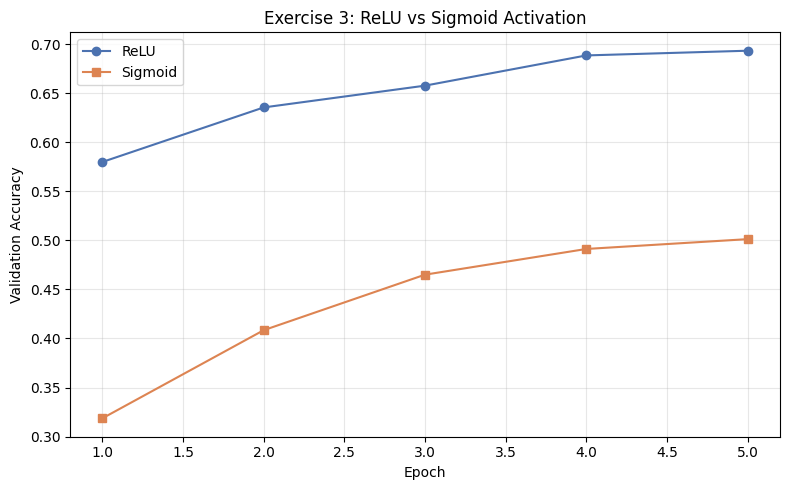


ReLU final val_accuracy: 0.6932
Sigmoid final val_accuracy: 0.5012

Training with 16 filters...
Epoch 1/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.4444 - loss: 1.5512 - val_accuracy: 0.5472 - val_loss: 1.2704
Epoch 2/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5758 - loss: 1.1976 - val_accuracy: 0.6052 - val_loss: 1.1140
Epoch 3/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6341 - loss: 1.0475 - val_accuracy: 0.6604 - val_loss: 1.0052
Epoch 4/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6662 - loss: 0.9532 - val_accuracy: 0.6660 - val_loss: 0.9679
Epoch 5/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6903 - loss: 0.8882 - val_accuracy: 0.6764 - val_loss: 0.9260

Training with 64 filters...
Epoch 1/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.4857 - loss: 1.4355 - val_accuracy: 0.5932 - val_loss: 1.1694
Epoch 2/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.6322 - loss: 1.0458 - val_accuracy: 0.6568 - va

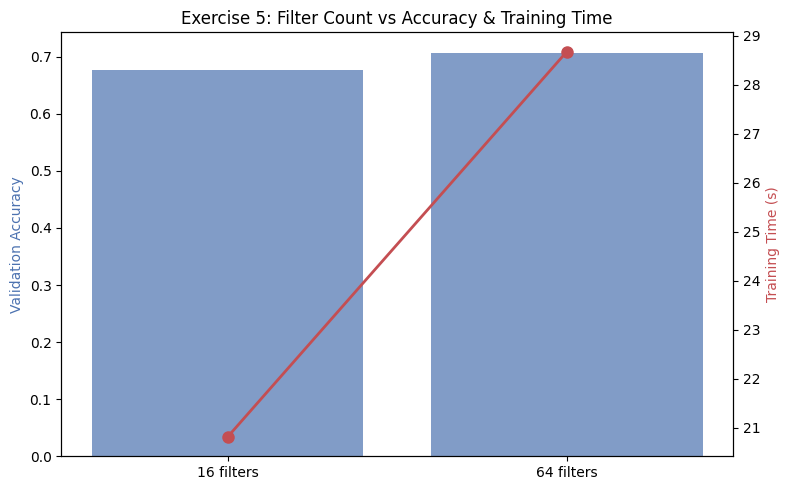

In [10]:
# Cell 9: Additional Exercises

# --- Exercise 1: Output size for 64x64 image, 5x5 kernel, stride 2, padding 2 ---
N, F, P, S = 64, 5, 2, 2
out_size = (N - F + 2*P) // S + 1
print(f"Exercise 1: Output size = ({N} - {F} + 2*{P})/{S} + 1 = {out_size}x{out_size}")

# --- Exercise 2: Trainable params, 64 filters of 3x3, RGB input ---
filters, k, in_channels = 64, 3, 3
params = (k * k * in_channels + 1) * filters
print(f"\nExercise 2: Trainable parameters = ({k}x{k}x{in_channels} + 1) x {filters} = {params}")

# --- Exercise 3: ReLU vs Sigmoid activation comparison ---
def build_activation_cnn(activation='relu'):
    m = keras.Sequential([
        keras.layers.Conv2D(32, (3,3), activation=activation, padding='same', input_shape=(32,32,3)),
        keras.layers.MaxPooling2D((2,2)),
        keras.layers.Conv2D(64, (3,3), activation=activation, padding='same'),
        keras.layers.MaxPooling2D((2,2)),
        keras.layers.Flatten(),
        keras.layers.Dense(128, activation=activation),
        keras.layers.Dense(10, activation='softmax')
    ])
    m.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return m

print("\nTraining with ReLU (5 epochs, quick comparison)...")
model_relu = build_activation_cnn('relu')
hist_relu = model_relu.fit(X_train_norm, y_train, epochs=5, batch_size=64,
                            validation_split=0.1, verbose=1)

print("\nTraining with Sigmoid (5 epochs, quick comparison)...")
model_sigmoid = build_activation_cnn('sigmoid')
hist_sigmoid = model_sigmoid.fit(X_train_norm, y_train, epochs=5, batch_size=64,
                                  validation_split=0.1, verbose=1)

plt.figure(figsize=(8,5))
plt.plot(range(1,6), hist_relu.history['val_accuracy'], 'o-', label='ReLU', color='#4C72B0')
plt.plot(range(1,6), hist_sigmoid.history['val_accuracy'], 's-', label='Sigmoid', color='#DD8452')
plt.xlabel('Epoch'); plt.ylabel('Validation Accuracy')
plt.title('Exercise 3: ReLU vs Sigmoid Activation')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig('/content/plots/12_relu_vs_sigmoid.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nReLU final val_accuracy: {hist_relu.history['val_accuracy'][-1]:.4f}")
print(f"Sigmoid final val_accuracy: {hist_sigmoid.history['val_accuracy'][-1]:.4f}")

# --- Exercise 5: Filter count 16 vs 64 comparison (accuracy + time) ---
import time

def build_filter_cnn(f1, f2):
    m = keras.Sequential([
        keras.layers.Conv2D(f1, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
        keras.layers.MaxPooling2D((2,2)),
        keras.layers.Conv2D(f2, (3,3), activation='relu', padding='same'),
        keras.layers.MaxPooling2D((2,2)),
        keras.layers.Flatten(),
        keras.layers.Dense(128, activation='relu'),
        keras.layers.Dense(10, activation='softmax')
    ])
    m.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return m

print("\nTraining with 16 filters...")
start = time.time()
model_16 = build_filter_cnn(16, 32)
hist_16 = model_16.fit(X_train_norm, y_train, epochs=5, batch_size=64, validation_split=0.1, verbose=1)
time_16 = time.time() - start

print("\nTraining with 64 filters...")
start = time.time()
model_64 = build_filter_cnn(64, 128)
hist_64 = model_64.fit(X_train_norm, y_train, epochs=5, batch_size=64, validation_split=0.1, verbose=1)
time_64 = time.time() - start

print(f"\n16 filters -> val_acc: {hist_16.history['val_accuracy'][-1]:.4f}, time: {time_16:.1f}s, params: {model_16.count_params():,}")
print(f"64 filters -> val_acc: {hist_64.history['val_accuracy'][-1]:.4f}, time: {time_64:.1f}s, params: {model_64.count_params():,}")

fig, ax1 = plt.subplots(figsize=(8,5))
x = ['16 filters', '64 filters']
accs = [hist_16.history['val_accuracy'][-1], hist_64.history['val_accuracy'][-1]]
times = [time_16, time_64]
ax1.bar(x, accs, color='#4C72B0', alpha=0.7, label='Val Accuracy')
ax1.set_ylabel('Validation Accuracy', color='#4C72B0')
ax2 = ax1.twinx()
ax2.plot(x, times, 'o-', color='#C44E52', linewidth=2, markersize=8, label='Training Time')
ax2.set_ylabel('Training Time (s)', color='#C44E52')
plt.title('Exercise 5: Filter Count vs Accuracy & Training Time')
plt.tight_layout()
plt.savefig('/content/plots/13_filter_count_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

Exercise 1: Output size = (64 - 5 + 2*2)/2 + 1 = 32x32

Exercise 2: Trainable parameters = (3x3x3 + 1) x 64 = 1792

Training with ReLU (5 epochs, quick comparison)...
Epoch 1/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.4765 - loss: 1.4580 - val_accuracy: 0.5850 - val_loss: 1.2005
Epoch 2/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6169 - loss: 1.0939 - val_accuracy: 0.6552 - val_loss: 1.0109
Epoch 3/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6693 - loss: 0.9416 - val_accuracy: 0.6802 - val_loss: 0.9425
Epoch 4/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7093 - loss: 0.8401 - val_accuracy: 0.6816 - val_loss: 0.9287
Epoch 5/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7374 - loss: 0.7549 - val_accuracy: 0.7112 - val_loss: 0.8759

Training with Sigmoid (5 epochs, quick comparison)...
Epoch 1/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.2208 - loss: 2.1119 - val_accuracy: 0.3092 - val_loss: 1.9264
Epoch 2/5
704/70

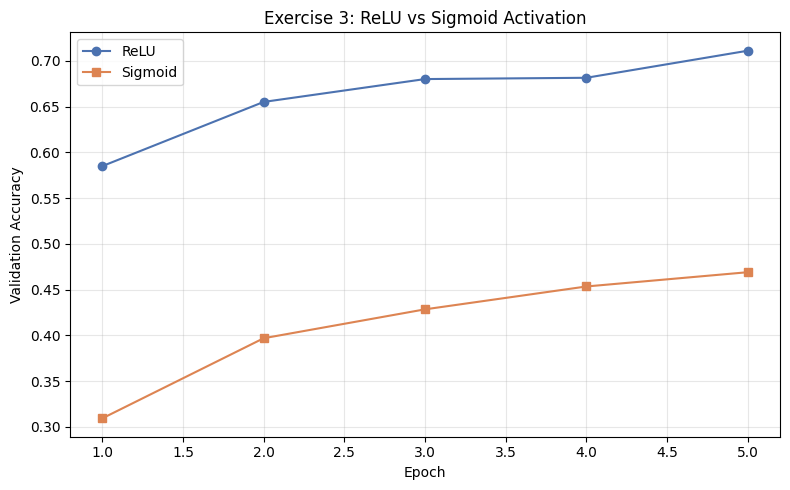


ReLU final val_accuracy: 0.7112
Sigmoid final val_accuracy: 0.4690

Training with 16 filters...
Epoch 1/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.4542 - loss: 1.5230 - val_accuracy: 0.5334 - val_loss: 1.3396
Epoch 2/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5760 - loss: 1.1956 - val_accuracy: 0.6012 - val_loss: 1.1296
Epoch 3/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6262 - loss: 1.0580 - val_accuracy: 0.6382 - val_loss: 1.0312
Epoch 4/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6627 - loss: 0.9605 - val_accuracy: 0.6752 - val_loss: 0.9484
Epoch 5/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6893 - loss: 0.8830 - val_accuracy: 0.6800 - val_loss: 0.9265

Training with 64 filters...
Epoch 1/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.4947 - loss: 1.4121 - val_accuracy: 0.5912 - val_loss: 1.1735
Epoch 2/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6447 - loss: 1.0216 - val_accuracy: 0.6830 - v

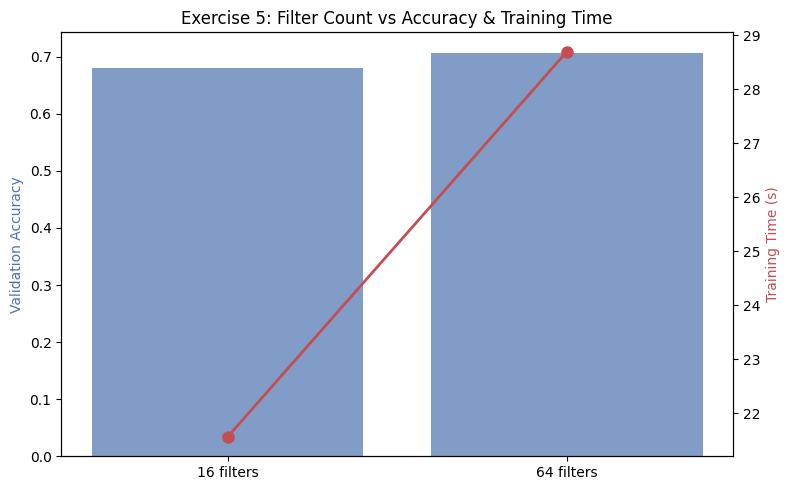

In [11]:
# Cell 9: Additional Exercises

# --- Exercise 1: Output size for 64x64 image, 5x5 kernel, stride 2, padding 2 ---
N, F, P, S = 64, 5, 2, 2
out_size = (N - F + 2*P) // S + 1
print(f"Exercise 1: Output size = ({N} - {F} + 2*{P})/{S} + 1 = {out_size}x{out_size}")

# --- Exercise 2: Trainable params, 64 filters of 3x3, RGB input ---
filters, k, in_channels = 64, 3, 3
params = (k * k * in_channels + 1) * filters
print(f"\nExercise 2: Trainable parameters = ({k}x{k}x{in_channels} + 1) x {filters} = {params}")

# --- Exercise 3: ReLU vs Sigmoid activation comparison ---
def build_activation_cnn(activation='relu'):
    m = keras.Sequential([
        keras.layers.Conv2D(32, (3,3), activation=activation, padding='same', input_shape=(32,32,3)),
        keras.layers.MaxPooling2D((2,2)),
        keras.layers.Conv2D(64, (3,3), activation=activation, padding='same'),
        keras.layers.MaxPooling2D((2,2)),
        keras.layers.Flatten(),
        keras.layers.Dense(128, activation=activation),
        keras.layers.Dense(10, activation='softmax')
    ])
    m.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return m

print("\nTraining with ReLU (5 epochs, quick comparison)...")
model_relu = build_activation_cnn('relu')
hist_relu = model_relu.fit(X_train_norm, y_train, epochs=5, batch_size=64,
                            validation_split=0.1, verbose=1)

print("\nTraining with Sigmoid (5 epochs, quick comparison)...")
model_sigmoid = build_activation_cnn('sigmoid')
hist_sigmoid = model_sigmoid.fit(X_train_norm, y_train, epochs=5, batch_size=64,
                                  validation_split=0.1, verbose=1)

plt.figure(figsize=(8,5))
plt.plot(range(1,6), hist_relu.history['val_accuracy'], 'o-', label='ReLU', color='#4C72B0')
plt.plot(range(1,6), hist_sigmoid.history['val_accuracy'], 's-', label='Sigmoid', color='#DD8452')
plt.xlabel('Epoch'); plt.ylabel('Validation Accuracy')
plt.title('Exercise 3: ReLU vs Sigmoid Activation')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig('/content/plots/12_relu_vs_sigmoid.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nReLU final val_accuracy: {hist_relu.history['val_accuracy'][-1]:.4f}")
print(f"Sigmoid final val_accuracy: {hist_sigmoid.history['val_accuracy'][-1]:.4f}")

# --- Exercise 5: Filter count 16 vs 64 comparison (accuracy + time) ---
import time

def build_filter_cnn(f1, f2):
    m = keras.Sequential([
        keras.layers.Conv2D(f1, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
        keras.layers.MaxPooling2D((2,2)),
        keras.layers.Conv2D(f2, (3,3), activation='relu', padding='same'),
        keras.layers.MaxPooling2D((2,2)),
        keras.layers.Flatten(),
        keras.layers.Dense(128, activation='relu'),
        keras.layers.Dense(10, activation='softmax')
    ])
    m.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return m

print("\nTraining with 16 filters...")
start = time.time()
model_16 = build_filter_cnn(16, 32)
hist_16 = model_16.fit(X_train_norm, y_train, epochs=5, batch_size=64, validation_split=0.1, verbose=1)
time_16 = time.time() - start

print("\nTraining with 64 filters...")
start = time.time()
model_64 = build_filter_cnn(64, 128)
hist_64 = model_64.fit(X_train_norm, y_train, epochs=5, batch_size=64, validation_split=0.1, verbose=1)
time_64 = time.time() - start

print(f"\n16 filters -> val_acc: {hist_16.history['val_accuracy'][-1]:.4f}, time: {time_16:.1f}s, params: {model_16.count_params():,}")
print(f"64 filters -> val_acc: {hist_64.history['val_accuracy'][-1]:.4f}, time: {time_64:.1f}s, params: {model_64.count_params():,}")

fig, ax1 = plt.subplots(figsize=(8,5))
x = ['16 filters', '64 filters']
accs = [hist_16.history['val_accuracy'][-1], hist_64.history['val_accuracy'][-1]]
times = [time_16, time_64]
ax1.bar(x, accs, color='#4C72B0', alpha=0.7, label='Val Accuracy')
ax1.set_ylabel('Validation Accuracy', color='#4C72B0')
ax2 = ax1.twinx()
ax2.plot(x, times, 'o-', color='#C44E52', linewidth=2, markersize=8, label='Training Time')
ax2.set_ylabel('Training Time (s)', color='#C44E52')
plt.title('Exercise 5: Filter Count vs Accuracy & Training Time')
plt.tight_layout()
plt.savefig('/content/plots/13_filter_count_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

In [12]:
# Cell 10: Zip all plots for download
import shutil
from google.colab import files

zip_path = '/content/CNN_CIFAR10_plots'
shutil.make_archive(zip_path, 'zip', '/content/plots')

print("Files included in zip:")
for f in sorted(os.listdir('/content/plots')):
    print(f"  - {f}")

files.download(zip_path + '.zip')

Files included in zip:
  - 01_sample_images.png
  - 02_class_distribution.png
  - 03_kernel_size_comparison.png
  - 04_stride_padding_comparison.png
  - 05_feature_maps_first_conv.png
  - 06_pooling_output_comparison.png
  - 07_pooling_accuracy_comparison.png
  - 08_training_accuracy.png
  - 08a_training_accuracy_only.png
  - 08b_validation_accuracy_only.png
  - 09_training_loss.png
  - 09a_training_loss_only.png
  - 09b_validation_loss_only.png
  - 10_confusion_matrix.png
  - 11_per_class_accuracy.png
  - 12_relu_vs_sigmoid.png
  - 13_filter_count_comparison.png
  - classification_report.txt
  - model_summary.txt


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>